# Step 1: Spark Session Initialization
In Azure Databricks, the Spark environment is pre-configured. We simply create a Spark session to start working with big data using PySpark.

In [0]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("Education_Nutrition_Analysis").getOrCreate()

# Step 2: Load datasets from Azure Blob Storage
We'll load the student performance and nutrition datasets directly from Azure Blob Storage into Databricks.

In [0]:
# Azure Blob Storage configuration (example configuration)
spark.conf.set(
    "fs.azure.account.key.yourstorageaccount.blob.core.windows.net",
    "YOUR_STORAGE_ACCOUNT_KEY"
)

# Example dataset paths
student_path = "wasbs://your-container@yourstorageaccount.blob.core.windows.net/student_performance.csv"
diet_path = "wasbs://your-container@yourstorageaccount.blob.core.windows.net/diet_recommendations.csv"

# Read CSV files into Spark DataFrames
student_df = spark.read.csv(student_path, header=True, inferSchema=True)
diet_df = spark.read.csv(diet_path, header=True, inferSchema=True)

# Preview datasets
student_df.show(5)
diet_df.show(5)

+-------+------+--------------+---------------------------+-----+-----------------------+----------+-------------+-------------+-------------+-----------+-----+
|roll_no|gender|race_ethnicity|parental_level_of_education|lunch|test_preparation_course|math_score|reading_score|writing_score|science_score|total_score|grade|
+-------+------+--------------+---------------------------+-----+-----------------------+----------+-------------+-------------+-------------+-----------+-----+
| std-01|  male|       group D|               some college|    1|                      1|        89|           38|           85|           26|        238|    C|
| std-02|  male|       group B|                high school|    1|                      0|        65|          100|           67|           96|        328|    A|
| std-03|  male|       group C|            master's degree|    1|                      0|        10|           99|           97|           58|        264|    B|
| std-04|  male|       group D|   

# Step 3: Preprocessing – Gender Normalization & Grade Conversion

We clean the datasets by standardizing gender labels and converting letter grades to a 100-point numeric scale.

Then, we compute the average numeric grade by gender and translate it back to a letter format for easier interpretation.

In [0]:
from pyspark.sql.functions import trim, lower, when, col

# Standardize gender in student dataset
student_df = student_df.withColumn(
    "gender",
    when(trim(lower(col("gender"))).isin("male", "boy", "tmale"), "male")
    .when(trim(lower(col("gender"))).isin("female", "girl"), "female")
    .otherwise("other")
)

# Standardize gender in diet dataset
diet_df = diet_df.withColumn(
    "Gender",
    when(trim(lower(col("Gender"))) == "male", "male")
    .when(trim(lower(col("Gender"))) == "female", "female")
    .otherwise("other")
)

# Show updated values
print("Unique values in student_df:")
student_df.select("gender").distinct().show()

print("Unique values in diet_df:")
diet_df.select("Gender").distinct().show()

Unique values in student_df:
+------+
|gender|
+------+
|female|
| other|
|  male|
+------+

Unique values in diet_df:
+------+
|Gender|
+------+
|female|
| other|
|  male|
+------+



# Step 4: Map letter grades to custom numeric values
We assign numeric scores to letter grades using a scale out of 100:
- A = 100, B = 75, C = 50, D = 25, F = 0


In [0]:
from pyspark.sql.functions import when

# Convert letter grades to numeric using 100-point scale
student_df = student_df.withColumn(
    "grade_numeric",
    when(col("grade") == "A", 100)
    .when(col("grade") == "B", 75)
    .when(col("grade") == "C", 50)
    .when(col("grade") == "D", 25)
    .otherwise(0)
)

# Show results
student_df.select("gender", "grade", "grade_numeric").show(10)

+------+-----+-------------+
|gender|grade|grade_numeric|
+------+-----+-------------+
|  male|    C|           50|
|  male|    A|          100|
|  male|    B|           75|
|  male|    D|           25|
|  male|    C|           50|
|  male|    C|           50|
| other|    C|           50|
|  male|    D|           25|
|  male|    B|           75|
|  male|    C|           50|
+------+-----+-------------+
only showing top 10 rows



# Step 5: Insight 1– Average Grade by Gender
We calculate the average numeric grade for each gender, then map the average back to a letter grade for easier interpretation.

This gives us a quick visual of which gender groups are performing better on average.


In [0]:
from pyspark.sql.functions import avg

# Step 1: Calculate average numeric grade by gender
avg_grade_df = student_df.groupBy("gender").agg(
    avg("grade_numeric").alias("avg_grade_score")
)

# Step 2: Convert average score back to letter grade
avg_grade_df = avg_grade_df.withColumn(
    "avg_grade_letter",
    when(col("avg_grade_score") >= 87.5, "A")
    .when(col("avg_grade_score") >= 62.5, "B")
    .when(col("avg_grade_score") >= 37.5, "C")
    .when(col("avg_grade_score") >= 12.5, "D")
    .otherwise("F")
)

# Show results
avg_grade_df.show()

+------+-----------------+----------------+
|gender|  avg_grade_score|avg_grade_letter|
+------+-----------------+----------------+
|female|71.95073102343281|               B|
| other|64.47368421052632|               B|
|  male|61.38231756214916|               C|
+------+-----------------+----------------+



# Step 7a: Insight 2– Health, Diet, and Sleep Trends by Gender

We create binary flags to represent:
- Whether a student is affected by any chronic disease (`is_unhealthy`)
- Whether they were recommended a nutritionally balanced or high-protein meal plan (`has_good_diet`)

Using these indicators, we calculate wellness metrics for each gender group:
- Percent diagnosed with a health condition
- Percent recommended a good diet
- Average sleep hours


In [0]:
from pyspark.sql.functions import when, count, avg

# Add binary flags
diet_df = diet_df.withColumn(
    "is_unhealthy", when((col("Chronic_Disease") != "None") & col("Chronic_Disease").isNotNull(), 1).otherwise(0)
)

diet_df = diet_df.withColumn(
    "has_good_diet", when(col("Recommended_Meal_Plan").isin("Balanced Diet", "High-Protein Diet"), 1).otherwise(0)
)

# Group and calculate metrics
diet_insight_df = diet_df.groupBy("Gender").agg(
    count("*").alias("total_users"),
    avg("is_unhealthy").alias("percent_unhealthy"),
    avg("has_good_diet").alias("percent_good_diet"),
    avg("Sleep_Hours").alias("avg_sleep_hours")
).withColumnRenamed("Gender", "gender")

# Show the insight table
diet_insight_df.show()

+------+-----------+------------------+------------------+-----------------+
|gender|total_users| percent_unhealthy| percent_good_diet|  avg_sleep_hours|
+------+-----------+------------------+------------------+-----------------+
|female|       1695|0.6023598820058997| 0.512684365781711|7.022890855457231|
| other|       1653|0.5801572897761645|0.4827586206896552| 7.02177858439201|
|  male|       1652|0.5914043583535109|0.5072639225181598|7.014285714285718|
+------+-----------+------------------+------------------+-----------------+



# Step 7b: Format Percentages for Readability

We multiply the `percent_unhealthy` and `percent_good_diet` columns by 100 and round them to 2 decimal places for better readability and reporting clarity.


In [0]:
from pyspark.sql.functions import round

# Convert proportions to percentages and round to 2 decimal places
diet_insight_df = diet_insight_df.withColumn("percent_unhealthy", round(col("percent_unhealthy") * 100, 2)) \
                                 .withColumn("percent_good_diet", round(col("percent_good_diet") * 100, 2))

# Show the updated table
diet_insight_df.show()

+------+-----------+-----------------+-----------------+-----------------+
|gender|total_users|percent_unhealthy|percent_good_diet|  avg_sleep_hours|
+------+-----------+-----------------+-----------------+-----------------+
|female|       1695|            60.24|            51.27|7.022890855457231|
| other|       1653|            58.02|            48.28| 7.02177858439201|
|  male|       1652|            59.14|            50.73|7.014285714285718|
+------+-----------+-----------------+-----------------+-----------------+



# Step 8: Visualising Average Grade by Gender

We use Seaborn to create a bar plot of average academic performance by gender.

This visual highlights the comparative performance of gender groups, giving a quick overview of who is performing better on average.

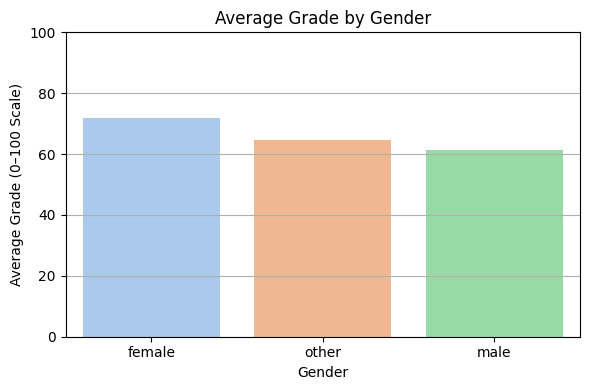

In [0]:
# Convert Spark DataFrame to Pandas for visualization
avg_grade_pd = avg_grade_df.toPandas()

# Plot: Gender vs Average Grade (numeric)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
# Create the bar plot without using 'hue' for a single category bar per gender
bar_plot = sns.barplot(data=avg_grade_pd, x="gender", y="avg_grade_score", palette="pastel")

plt.title("Average Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Grade (0–100 Scale)")
plt.ylim(0, 100)
plt.grid(axis='y')

# Customizing legend if necessary, otherwise remove or comment it out
# Since 'hue' is not used, no legend is needed unless there are multiple categories
# plt.legend(title='Gender')  # Optional, only include if there are multiple categories

plt.tight_layout()
plt.show()

# Step 9: Visualising Wellness Trends by Gender

We generate bar plots for wellness indicators across gender groups:

1. **Percentage of students with chronic health conditions**
2. **Percentage recommended a nutritionally balanced or high-protein diet**
3. **Average sleep hours per gender group**

These visualizations help highlight lifestyle differences and wellness patterns among different gender groups.


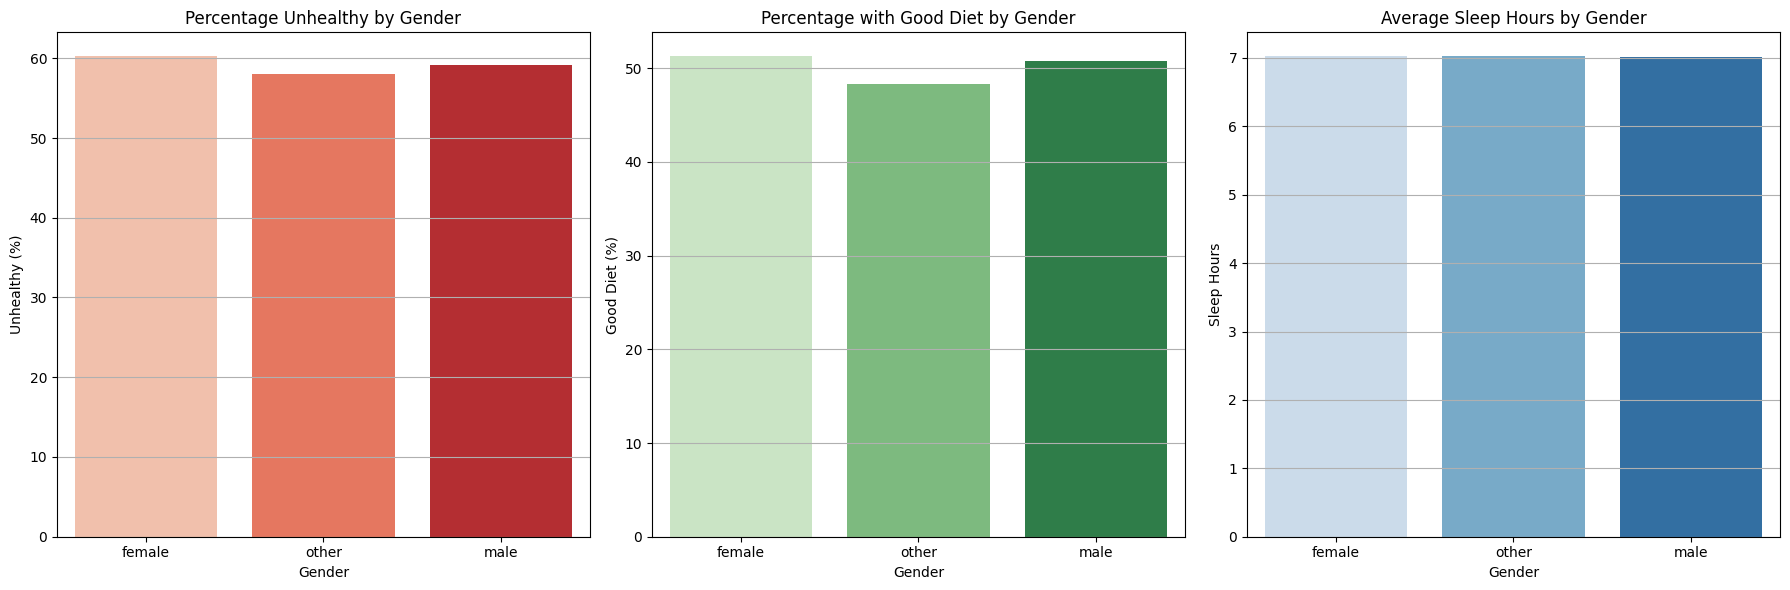

In [0]:
# Convert Spark DataFrame to Pandas first
diet_insight_pd = diet_insight_df.toPandas()

# Now do the plotting
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 3 subplots in 1 row

# Plot 1: Gender vs Percent Unhealthy
sns.barplot(ax=axes[0], data=diet_insight_pd, x="gender", y="percent_unhealthy", palette="Reds")
axes[0].set_title("Percentage Unhealthy by Gender")
axes[0].set_ylabel("Unhealthy (%)")
axes[0].set_xlabel("Gender")
axes[0].grid(axis='y')

# Plot 2: Gender vs Percent Good Diet
sns.barplot(ax=axes[1], data=diet_insight_pd, x="gender", y="percent_good_diet", palette="Greens")
axes[1].set_title("Percentage with Good Diet by Gender")
axes[1].set_ylabel("Good Diet (%)")
axes[1].set_xlabel("Gender")
axes[1].grid(axis='y')

# Plot 3: Gender vs Average Sleep Hours
sns.barplot(ax=axes[2], data=diet_insight_pd, x="gender", y="avg_sleep_hours", palette="Blues")
axes[2].set_title("Average Sleep Hours by Gender")
axes[2].set_ylabel("Sleep Hours")
axes[2].set_xlabel("Gender")
axes[2].grid(axis='y')

plt.tight_layout()
plt.show()


# Step 10a: Correlation Between Wellness and Performance

We join the academic and wellness datasets on the `gender` column and analyze how wellness indicators correlate with students' average grades.

This correlation helps identify which wellness factors most significantly influence academic performance.


In [0]:
# Join both datasets on 'gender'
combined_df = student_df.join(diet_insight_df, on="gender", how="inner")

# Select important numeric features
cols_to_analyze = ["grade_numeric", "percent_unhealthy", "percent_good_diet", "avg_sleep_hours"]
combined_df = combined_df.select(cols_to_analyze)

# Calculate and display correlation between grade and each wellness factor
for col_name in cols_to_analyze[1:]:
    corr = combined_df.stat.corr("grade_numeric", col_name)
    print(f"Correlation between grade and {col_name}: {corr:.4f}")

Correlation between grade and percent_unhealthy: 0.2764
Correlation between grade and percent_good_diet: 0.2567
Correlation between grade and avg_sleep_hours: 0.2779


# Step 10b: Visual Interpretation of Correlation Trends

To visually interpret the relationship between wellness and performance, we use a custom summary DataFrame with key metrics across gender groups.

Each subplot compares a wellness factor (unhealthy %, good diet %, sleep hours) with average grade.

This side-by-side view highlights potential relationships and differences across gender groups.


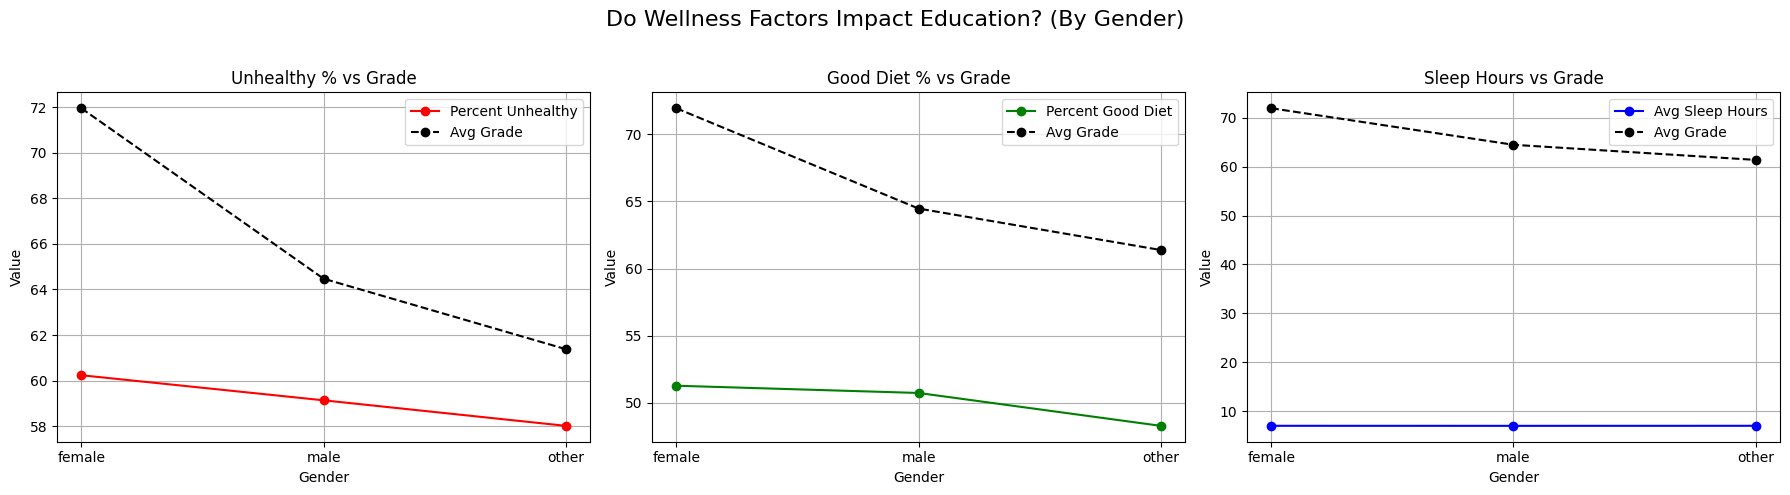

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

# Data setup
data = {
    "gender": ["female", "male", "other"],
    "avg_grade_numeric": [71.95073102343281, 64.47368421052632, 61.38231756214916],
    "percent_unhealthy": [60.24, 59.14, 58.02],
    "percent_good_diet": [51.27, 50.73, 48.28],
    "avg_sleep_hours": [7.02, 7.01, 7.02]
}
df = pd.DataFrame(data)

# Create horizontally aligned line plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # Change to 1 row, 3 columns

metrics = ['percent_unhealthy', 'percent_good_diet', 'avg_sleep_hours']
titles = ['Unhealthy % vs Grade', 'Good Diet % vs Grade', 'Sleep Hours vs Grade']
colors = ['red', 'green', 'blue']

for i in range(3):
    ax = axes[i]
    ax.plot(df["gender"], df[metrics[i]], label=metrics[i].replace('_', ' ').title(), color=colors[i], marker='o')
    ax.plot(df["gender"], df["avg_grade_numeric"], label="Avg Grade", color='black', linestyle='--', marker='o')

    ax.set_title(titles[i])
    ax.set_xlabel("Gender")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True)

plt.suptitle("Do Wellness Factors Impact Education? (By Gender)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust the layout
plt.show()